In [9]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, precision_recall_fscore_support)
import joblib
import os
print("Imports completed. Running on:", os.name)


Imports completed. Running on: nt


In [10]:
# Data loading
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=4000,
                           n_features=12,
                           n_informative=8,
                           n_redundant=2,
                           n_clusters_per_class=2,
                           weights=[0.85, 0.15], # imbalanced like credit defaults
                           flip_y=0.02,
                           random_state=42)

In [11]:

import pandas as pd
feature_names = ['age', 'income', 'credit_amount', 'duration_months',
                 'num_existing_loans', 'num_dependents', 'employment_years',
                 'purpose_score', 'housing_score', 'savings_score',
                 'installment_rate', 'credit_history_score']
df = pd.DataFrame(X, columns=feature_names)
df['default'] = y

print("Synthetic dataset shape:", df.shape)
df.head()
# -------------------------------------------------------------------------
# Option B: If you have a CSV, comment out the synthetic dataset above and use:
# df = pd.read_csv('/path/to/your/credit_data.csv')
# Ensure the target column is named 'default' (0/1) or adjust the code below.

Synthetic dataset shape: (4000, 13)


,age,income,credit_amount,duration_months,num_existing_loans,num_dependents,employment_years,purpose_score,housing_score,savings_score,installment_rate,credit_history_score,default
0,0.433633,1.846608,-0.613407,-0.208299,1.509508,-2.649702,3.773584,-2.230554,2.415331,3.053391,-0.747189,0.247102,0
1,-2.080335,-1.034799,-0.030279,1.270420,0.521387,0.867954,1.714843,-2.273874,-0.628119,-0.176726,-0.664476,0.619160,0
2,1.595319,0.200985,1.492894,0.587603,0.502035,1.944419,0.777089,-1.669015,-1.643260,-0.719261,0.305949,-4.131663,1
3,-3.185594,1.384496,-0.589973,0.573256,2.371605,2.046771,-1.920696,-0.898035,0.713085,3.206571,0.603499,-0.613183,0
4,-3.111851,0.013357,-0.862541,0.497313,2.258373,1.507473,2.325209,1.142289,3.096340,9.855989,-4.337573,-1.679834,0


## Exploratory Data Analysis (EDA)
Look at class balance, basic statistics, and a few feature distributions.

Target distribution (counts):
default
0    3368
1     632
Name: count, dtype: int64

Target proportion:
default
0    0.842
1    0.158
Name: proportion, dtype: float64


,count,mean,std,min,25%,50%,75%,max
age,4000.0,-1.026592,1.827483,-7.426073,-2.241387,-1.000139,0.196049,5.790714
income,4000.0,0.032233,2.052546,-7.921038,-1.370766,0.070315,1.450466,7.404736
credit_amount,4000.0,0.010514,1.003112,-3.550170,-0.684847,0.031539,0.689500,3.574301
duration_months,4000.0,-0.005722,1.001394,-3.331915,-0.658943,-0.017634,0.653083,3.512196
num_existing_loans,4000.0,0.881739,1.764057,-5.961333,-0.276107,0.925675,2.077255,7.364403
num_dependents,4000.0,0.457565,1.443479,-4.174480,-0.504753,0.471449,1.405294,6.265193
employment_years,4000.0,0.991614,1.556222,-6.055058,-0.031217,1.004440,2.022589,7.619852
purpose_score,4000.0,0.142731,1.770909,-5.611400,-1.082628,0.180107,1.360507,7.237837
housing_score,4000.0,-0.140476,1.968393,-7.491109,-1.491721,-0.112336,1.229439,6.406367
savings_score,4000.0,1.004688,4.921201,-22.585420,-2.079134,1.417599,4.413679,18.829639


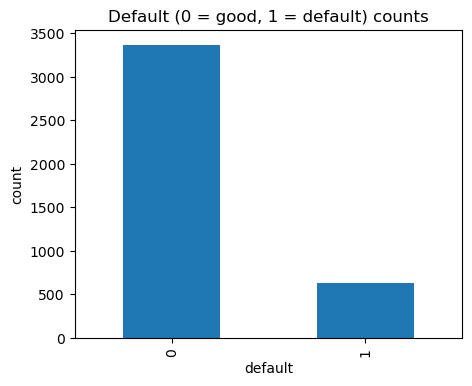

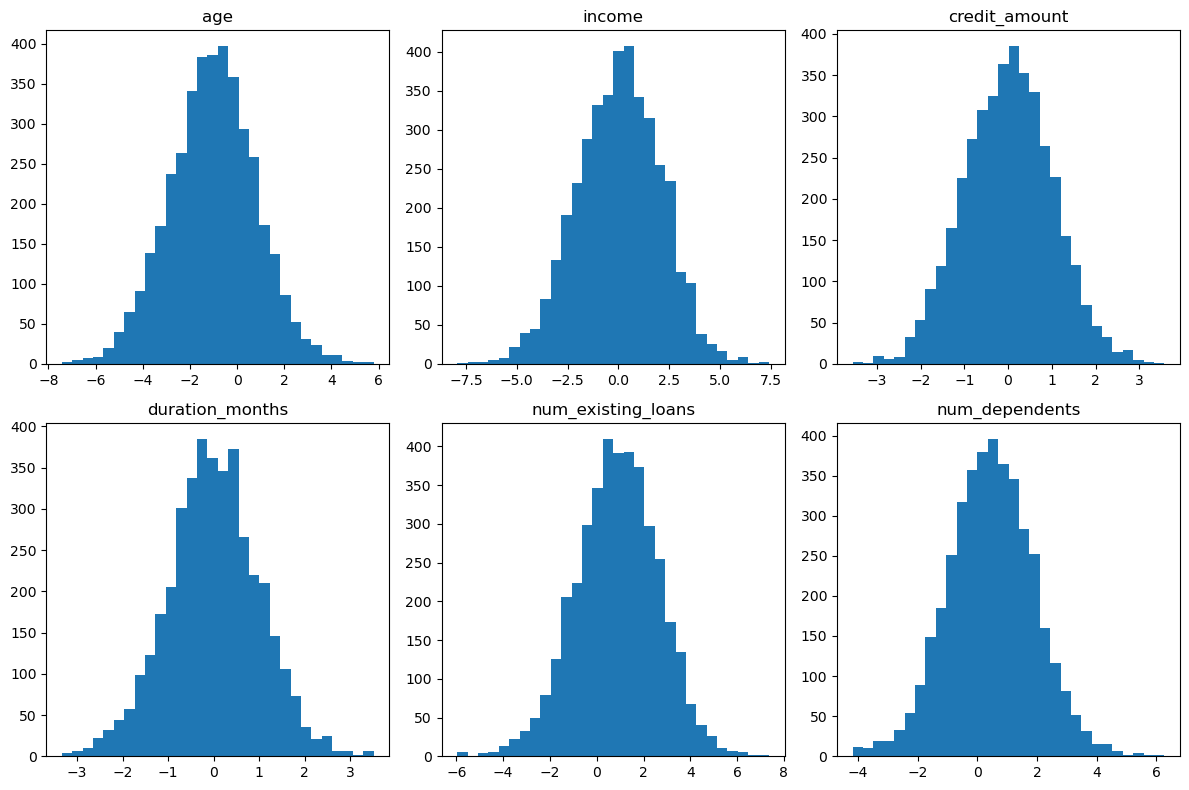

In [12]:
# Basic EDA
print('Target distribution (counts):')
print(df['default'].value_counts())
print('\nTarget proportion:')
print(df['default'].value_counts(normalize=True))

# Basic stats
display(df.describe().T)

# Plot class balance
plt.figure(figsize=(5,4))
df['default'].value_counts().plot(kind='bar')
plt.title('Default (0 = good, 1 = default) counts')
plt.xlabel('default')
plt.ylabel('count')
plt.show()

# Plotting a few feature distributions
plt.figure(figsize=(12,8))
for i, col in enumerate(feature_names[:6], 1):
    plt.subplot(2,3,i)
    plt.hist(df[col], bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()


## Preprocessing & Feature Engineering
This section shows a robust pipeline that handles numerical and categorical features. For the synthetic data we only have numerical features; when using a real dataset, add categorical columns to `categorical_features`.

In [13]:
# Identifying feature types 
numerical_features = feature_names  
categorical_features = [] 

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ], remainder='drop')


X = df[numerical_features + categorical_features]
y = df['default'].values
X_pre = preprocessor.fit_transform(X)
print('Transformed feature matrix shape:', X_pre.shape)


Transformed feature matrix shape: (4000, 12)


In [14]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,
                                                    test_size=0.2, random_state=42)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)


Train shape: (3200, 12) Test shape: (800, 12)


## Baseline Model: Logistic Regression
We'll build a pipeline combining preprocessing and a Logistic Regression baseline. Then evaluate and show ROC-AUC.

Classification report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.93      0.75      0.83       674
           1       0.35      0.70      0.46       126

    accuracy                           0.74       800
   macro avg       0.64      0.73      0.65       800
weighted avg       0.84      0.74      0.77       800

ROC AUC: 0.8111


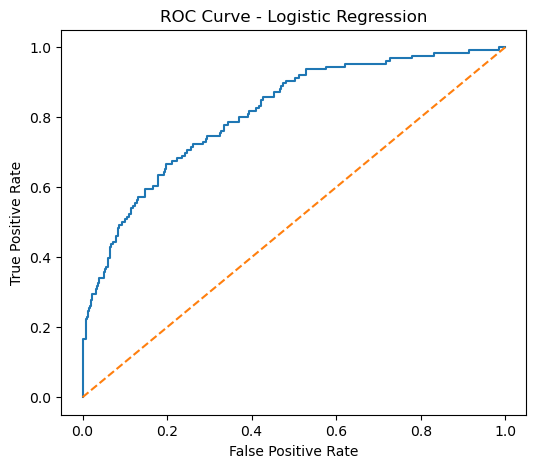

In [15]:
# Pipeline 
clf_lr = Pipeline(steps=[('preprocessor', preprocessor),
                         ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))])

clf_lr.fit(X_train, y_train)

# Predicting
y_pred = clf_lr.predict(X_test)
y_proba = clf_lr.predict_proba(X_test)[:,1]
print('Classification report (Logistic Regression):')
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
print('ROC AUC:', round(roc_auc,4))

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.show()


## Stronger Model: Random Forest
Try a Random Forest and a small grid search for a couple of hyperparameters.

Classification report (Random Forest):
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       674
           1       0.99      0.54      0.70       126

    accuracy                           0.93       800
   macro avg       0.95      0.77      0.83       800
weighted avg       0.93      0.93      0.92       800

ROC AUC (RF): 0.9358


housing_score           0.135979
savings_score           0.106792
num_existing_loans      0.105399
credit_history_score    0.100839
purpose_score           0.100786
age                     0.083973
installment_rate        0.081736
employment_years        0.075741
num_dependents          0.073531
income                  0.069597
dtype: float64

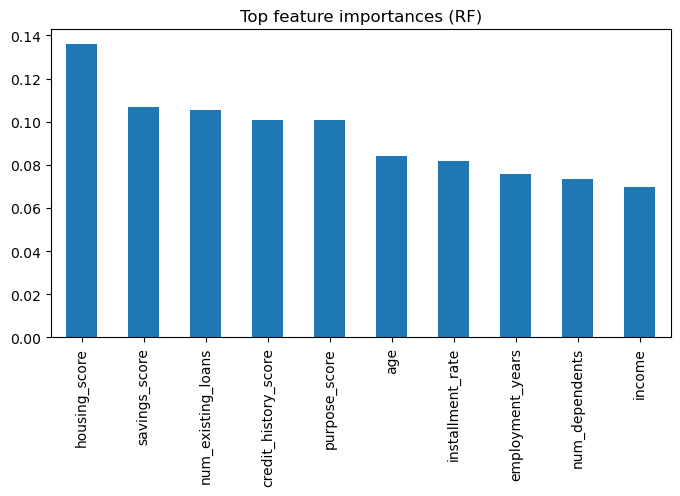

In [16]:
# Pipeline with Random Forest
clf_rf = Pipeline(steps=[('preprocessor', preprocessor),
                         ('classifier', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))])
# Fit
clf_rf.fit(X_train, y_train)

# Predicting
y_pred_rf = clf_rf.predict(X_test)
y_proba_rf = clf_rf.predict_proba(X_test)[:,1]
print('Classification report (Random Forest):')
print(classification_report(y_test, y_pred_rf))
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
print('ROC AUC (RF):', round(roc_auc_rf,4))


try:

    importances = clf_rf.named_steps['classifier'].feature_importances_
    names = numerical_features
    feat_imp = pd.Series(importances, index=names).sort_values(ascending=False)
    display(feat_imp.head(10))
    plt.figure(figsize=(8,4))
    feat_imp.head(10).plot(kind='bar')
    plt.title('Top feature importances (RF)')
    plt.show()
except Exception as e:
    print('Could not compute feature importances automatically:', e)


## Evaluation: Confusion Matrix and Business-oriented metrics

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
print('Confusion matrix (rows: true, cols: pred):')
print(cm)

# Compute precision, recall, f1 for positive class
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='binary')
print(f'Precision: {prec:.4f}, Recall (sensitivity): {rec:.4f}, F1: {f1:.4f}')

# Example:
threshold = 0.3
y_pred_thresh = (y_proba_rf >= threshold).astype(int)
prec_t, rec_t, f1_t, _ = precision_recall_fscore_support(y_test, y_pred_thresh, average='binary')
print(f'With threshold={threshold}: Precision={prec_t:.4f}, Recall={rec_t:.4f}, F1={f1_t:.4f}')


Confusion matrix (rows: true, cols: pred):
[[673   1]
 [ 58  68]]
Precision: 0.9855, Recall (sensitivity): 0.5397, F1: 0.6974
With threshold=0.3: Precision=0.8376, Recall=0.7778, F1=0.8066


In [19]:
# Saving the Random Forest pipeline
os.makedirs('/mnt/data/models', exist_ok=True)
model_path = '/mnt/data/models/credit_scoring_rf_pipeline.joblib'
joblib.dump(clf_rf, model_path)
print('Saved model to', model_path)

# loading and predicting example: 
loaded = joblib.load(model_path)
sample = X_test.iloc[:5]
print('Sample predictions:', loaded.predict(sample))
print('Sample probabilities:', loaded.predict_proba(sample)[:,1])


Saved model to /mnt/data/models/credit_scoring_rf_pipeline.joblib
Sample predictions: [0 1 1 0 0]
Sample probabilities: [0.24  0.615 0.595 0.025 0.05 ]
